# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [8]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 900,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_threshold': 2,
    'close_confidence': 1,  
    'reset_threshold': 2,
    'reset_confidence': 0,
    'gamma': 3,

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 900,

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [9]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=23,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 57
交易日范围: 20251201 ~ 20260227
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=23,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [10]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 886 个样本
20260106: 产生 820 个样本
20260107: 产生 875 个样本
20260108: 产生 807 个样本
20260109: 产生 831 个样本
20260112: 产生 914 个样本
20260113: 产生 812 个样本
20260114: 产生 861 个样本
20260115: 产生 862 个样本
20260116: 产生 879 个样本
20260119: 产生 845 个样本
20260120: 产生 867 个样本
20260121: 产生 903 个样本
20260122: 产生 846 个样本
20260123: 产生 894 个样本
20260126: 产生 934 个样本
20260127: 产生 894 个样本
20260128: 产生 888 个样本
20260129: 产生 913 个样本
20260130: 产生 947 个样本
20260202: 产生 938 个样本
20260203: 产生 895 个样本
20260204: 产生 867 个样本
20260205: 产生 913 个样本
20260206: 产生 882 个样本
20260209: 产生 892 个样本
20260210: 产生 927 个样本
20260211: 产生 889 个样本
20260212: 产生 858 个样本
20260213: 产生 866 个样本
20260224: 产生 936 个样本
20260225: 产生 909 个样本
20260226: 产生 898 个样本
20260227: 产生 875 个样本
训练集样本: X=(30023, 12), y=(30023,)


In [11]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 899 个样本
验证集样本: X=(899, 12), y=(899,)


In [12]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 899 个样本
20251202: 产生 893 个样本
20251203: 产生 894 个样本
20251204: 产生 851 个样本
20251205: 产生 932 个样本
20251208: 产生 883 个样本
20251209: 产生 874 个样本
20251210: 产生 849 个样本
20251211: 产生 809 个样本
20251212: 产生 924 个样本
20251215: 产生 888 个样本
20251216: 产生 879 个样本
20251217: 产生 941 个样本
20251218: 产生 891 个样本
20251219: 产生 926 个样本
20251222: 产生 886 个样本
20251223: 产生 882 个样本
20251224: 产生 885 个样本
20251225: 产生 948 个样本
20251226: 产生 927 个样本
20251229: 产生 878 个样本
20251230: 产生 860 个样本
20251231: 产生 865 个样本
测试集样本: X=(20464, 12), y=(20464,)


In [13]:
X_valid = X_test
y_valid = y_test

## 训练模型

In [14]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.69252
[100]	validation_0-logloss:0.64565
[200]	validation_0-logloss:0.62867
[300]	validation_0-logloss:0.62264
[400]	validation_0-logloss:0.62166
[500]	validation_0-logloss:0.62184
[600]	validation_0-logloss:0.62141
[700]	validation_0-logloss:0.62187
[800]	validation_0-logloss:0.62187
[900]	validation_0-logloss:0.62221
[1000]	validation_0-logloss:0.62257
[1100]	validation_0-logloss:0.62343
[1200]	validation_0-logloss:0.62452
[1300]	validation_0-logloss:0.62493
[1400]	validation_0-logloss:0.62610
[1500]	validation_0-logloss:0.62629
[1600]	validation_0-logloss:0.62687
[1700]	validation_0-logloss:0.62750
[1800]	validation_0-logloss:0.62777
[1900]	validation_0-logloss:0.62870
[1999]	validation_0-logloss:0.62906
阈值优化完成: Best Threshold=0.4397, F0.5=0.3673

特征重要性（前10个）:
volatility    0.175576
volume        0.123352
WAMP          0.112649
alpha_03      0.077186
alpha_04      0.076092
alpha_02      0.071397
alpha_05      0.068617
alpha_07      0.06855

In [15]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511090.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.5699

分类报告:
              precision    recall  f1-score   support

           0       0.78      0.56      0.66     14876
           1       0.34      0.59      0.43      5588

    accuracy                           0.57     20464
   macro avg       0.56      0.58      0.54     20464
weighted avg       0.66      0.57      0.59     20464


PR曲线AUC: 0.3447
平均精度 (AP): 0.3449

预测概率统计:
  均值: 0.4134
  标准差: 0.1485
  最小值: 0.0261
  25%分位数: 0.3186
  中位数: 0.4329
  75%分位数: 0.5238
  最大值: 0.7964

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3993, 标准差=0.1500
  标签1 (正类): 均值=0.4510, 标准差=0.1377


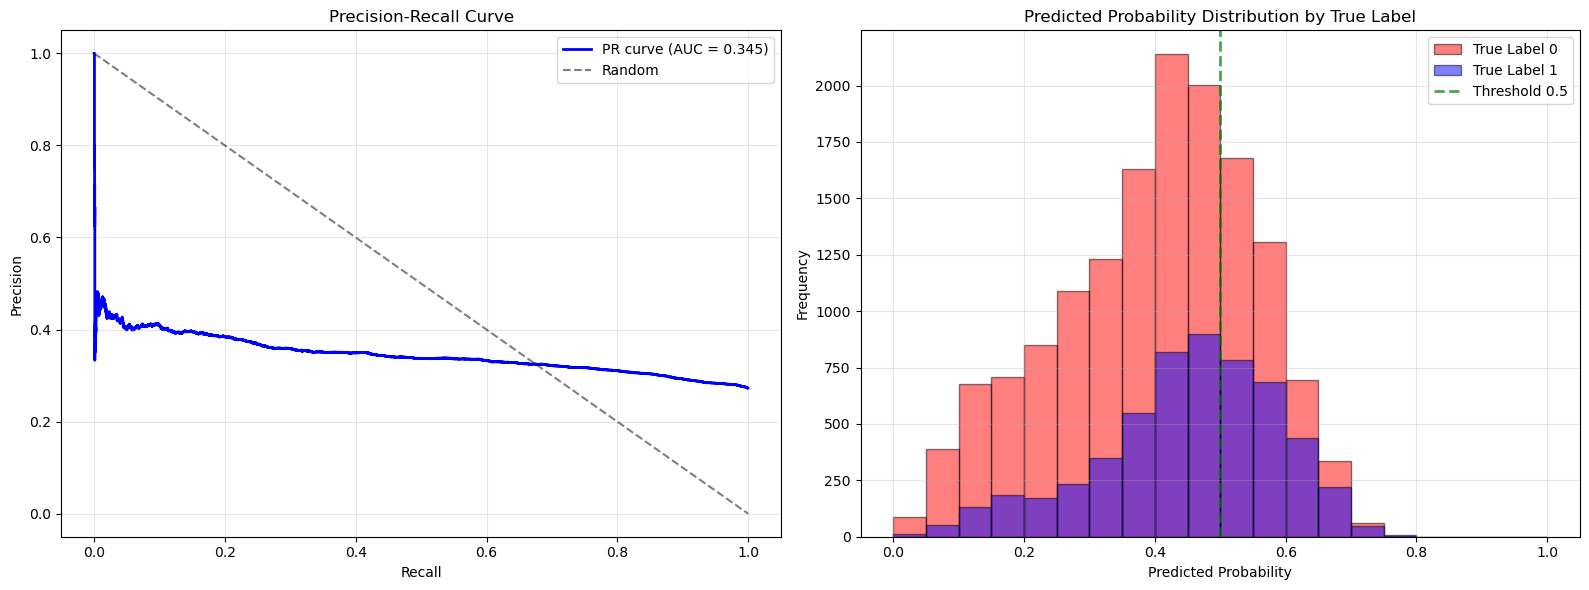

In [16]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [17]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 511090 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-1] 日期 20251201 完成 | 盈亏: 12.70 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 989.8快照
[SpawnPoolWorker-4] 日期 20251225 完成 | 盈亏: 1.30 | 成交: 13次 | 胜率: 38.5% | 平均持仓: 810.5快照
[SpawnPoolWorker-3] 日期 20251217 完成 | 盈亏: -22.70 | 成交: 9次 | 胜率: 33.3% | 平均持仓: 1288.2快照
[SpawnPoolWorker-2] 日期 20251209 完成 | 盈亏: 26.20 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 1140.4快照
[SpawnPoolWorker-1] 日期 20251202 完成 | 盈亏: 33.80 | 成交: 6次 | 胜率: 83.3% | 平均持仓: 930.5快照
[SpawnPoolWorker-4] 日期 20251226 完成 | 盈亏: -7.90 | 成交: 14次 | 胜率: 35.7% | 平均持仓: 709.1快照
[SpawnPoolWorker-3] 日期 20251218 完成 | 盈亏: 53.80 | 成交: 7次 | 胜率: 71.4% | 平均持仓: 1644.7快照
[SpawnPoolWorker-2] 日期 20251210 完成 | 盈亏: -1.60 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 984.2快照
[SpawnPoolWorker-1] 日期 20251203 完成 | 盈亏: 6.00 | 成交: 10次 | 胜率: 50.0% | 平均持仓: 960.6快照
[SpawnPoolWorker-4] 日期 20251229 完成 | 盈亏: -9.10 | 成交: 10次 | 胜率: 30.0% | 平均持仓: 1202.4快照
[SpawnPoolWorker-2] 日期 20251211 完成 | 盈亏: 1.10 | 成交: 11次 | 胜率: 45.5% | 平均持仓: 1023.5快照
[SpawnPoolWorker-3] 日期 20251219 完成 | 盈亏: 25.10 | 成交: 10次 | 胜率: 50

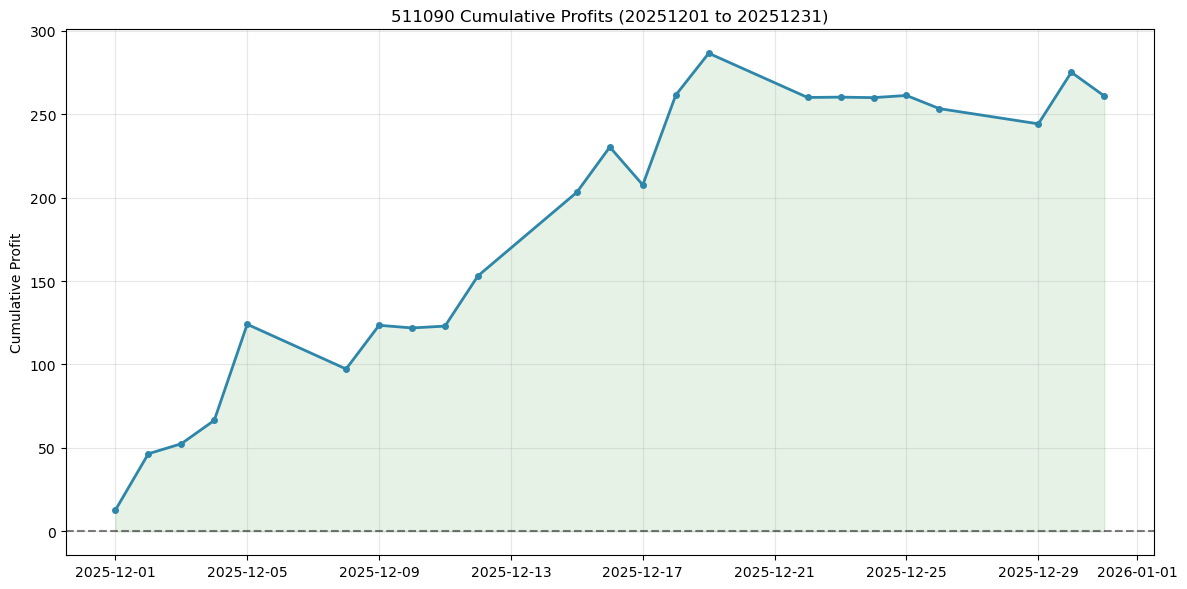


并行回测结果汇总:
{'测试天数': 23, '累计总盈亏': np.float64(260.9), '总成交次数': 229, '盈利交易次数': 106, '亏损交易次数': 123, '加权每手胜率%': np.float64(46.29), '日均盈亏': np.float64(11.34), '胜率(天)%': 65.22, '盈亏比(日均)': np.float64(1.81), '最大单日盈利': 57.6, '最大单日亏损': -26.8, '每笔交易平均盈利': np.float64(1.14), '加权平均持仓时间(快照)': np.float64(1044.1)}


In [18]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 34 个有数据的交易日
-> 过滤掉 331 个无数据日期: ['20260101', '20260102', '20260103', '20260104', '20260110', '20260111', '20260117', '20260118', '20260124', '20260125']...
-> 回测标的: 511090 (20260101 - 20261231)
-> 任务分配: 共 34 天，使用 4 个核心并行计算...


[SpawnPoolWorker-7] 日期 20260211 完成 | 盈亏: 8.50 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 1097.5快照
[SpawnPoolWorker-6] 日期 20260129 完成 | 盈亏: -12.40 | 成交: 13次 | 胜率: 30.8% | 平均持仓: 877.8快照
[SpawnPoolWorker-5] 日期 20260105 完成 | 盈亏: 17.20 | 成交: 12次 | 胜率: 41.7% | 平均持仓: 995.8快照
[SpawnPoolWorker-8] 日期 20260116 完成 | 盈亏: -5.90 | 成交: 14次 | 胜率: 35.7% | 平均持仓: 857.9快照
[SpawnPoolWorker-7] 日期 20260212 完成 | 盈亏: -4.30 | 成交: 13次 | 胜率: 46.1% | 平均持仓: 916.9快照
[SpawnPoolWorker-6] 日期 20260130 完成 | 盈亏: 2.90 | 成交: 12次 | 胜率: 25.0% | 平均持仓: 971.9快照
[SpawnPoolWorker-8] 日期 20260119 完成 | 盈亏: -10.00 | 成交: 13次 | 胜率: 38.5% | 平均持仓: 864.0快照
[SpawnPoolWorker-5] 日期 20260106 完成 | 盈亏: 17.80 | 成交: 12次 | 胜率: 41.7% | 平均持仓: 893.3快照
[SpawnPoolWorker-7] 日期 20260213 完成 | 盈亏: -28.10 | 成交: 15次 | 胜率: 26.7% | 平均持仓: 734.9快照
[SpawnPoolWorker-6] 日期 20260202 完成 | 盈亏: 27.70 | 成交: 9次 | 胜率: 66.7% | 平均持仓: 1229.4快照
[SpawnPoolWorker-8] 日期 20260120 完成 | 盈亏: -5.90 | 成交: 11次 | 胜率: 18.2% | 平均持仓: 1031.5快照
[SpawnPoolWorker-5] 日期 20260107 完成 | 盈亏: 60.60 | 成交: 12次 | 胜率:

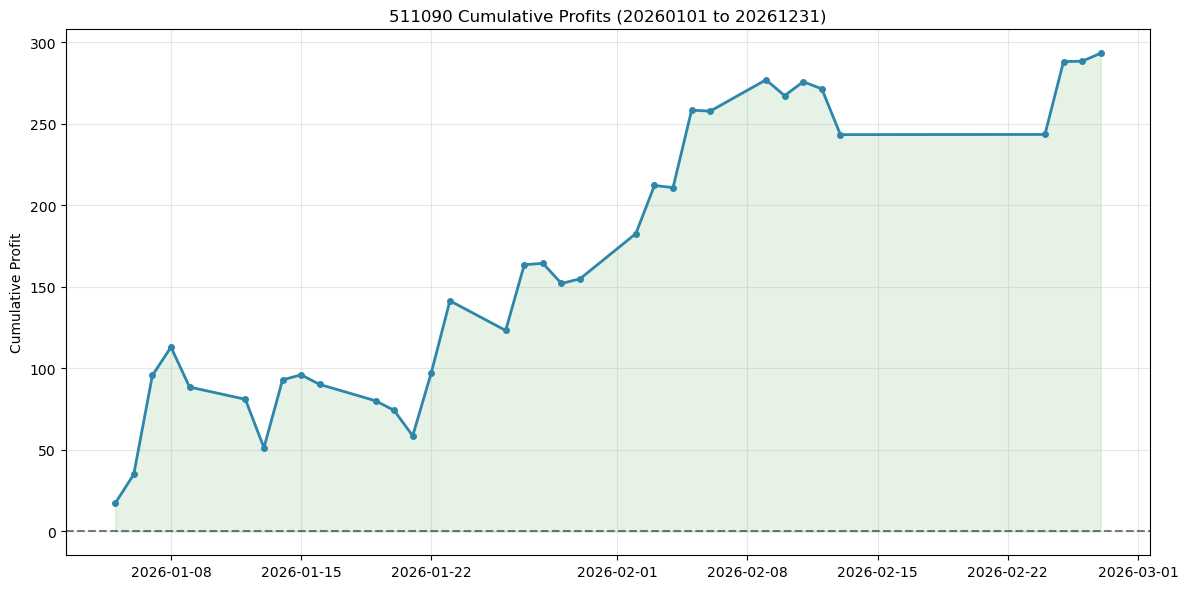


并行回测结果汇总:
{'测试天数': 34, '累计总盈亏': np.float64(293.2), '总成交次数': 402, '盈利交易次数': 170, '亏损交易次数': 232, '加权每手胜率%': np.float64(42.29), '日均盈亏': np.float64(8.62), '胜率(天)%': 58.82, '盈亏比(日均)': np.float64(1.88), '最大单日盈利': 60.6, '最大单日亏损': -29.7, '每笔交易平均盈利': np.float64(0.73), '加权平均持仓时间(快照)': np.float64(976.45)}


In [19]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20260101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [92]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260422_010643
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260422_010643
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [95]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260417", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260417_085159

总共删除了 1 个文件夹


## 单日回测观察

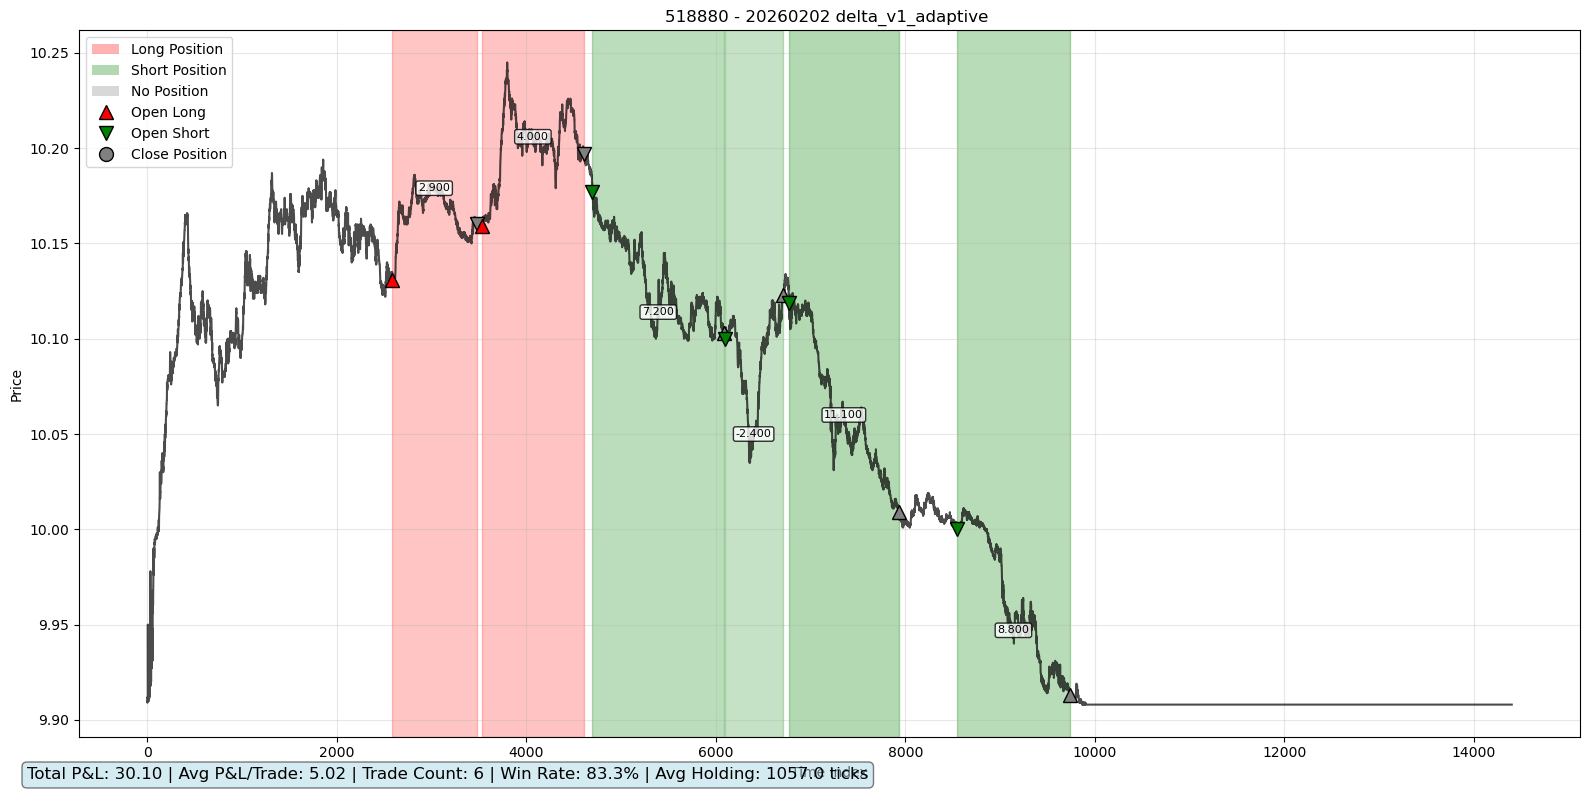

In [127]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20260202',StrategyDemo,model_path,param_dict,official = False)

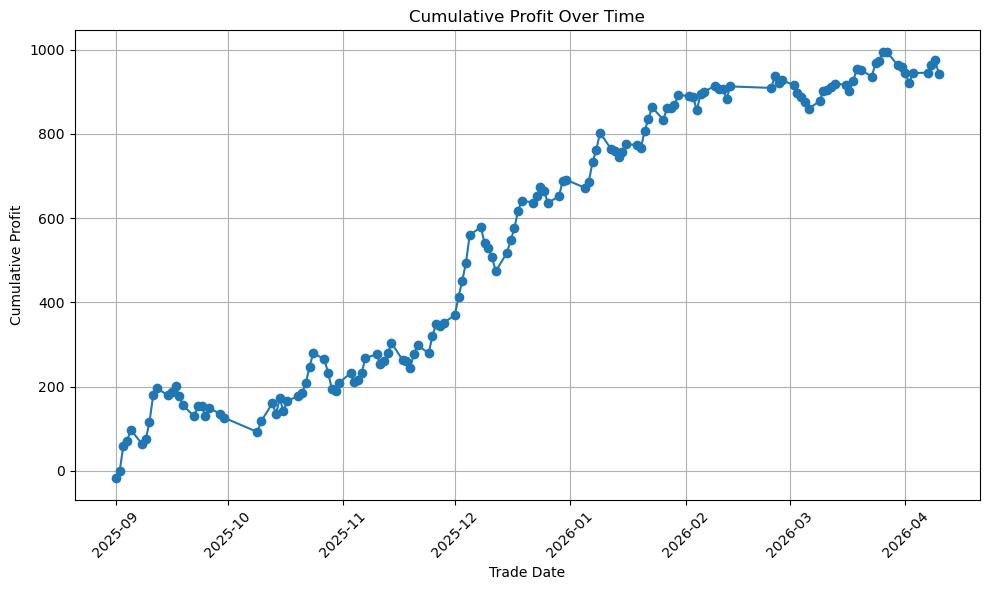

In [20]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
